# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mahmoud-Beram/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

Method: Random Forest Regressor to predict Expected CTR.
Why: The relationship between search position and CTR is highly non-linear (Position 1 is vastly different from Position 2, but Position 21 vs 22 is irrelevant). A Random Forest captures these non-linear steps perfectly. By predicting Expected CTR based on position and impressions, we can identify "CTR Gap" opportunities (Actual CTR << Expected CTR) more intelligently than a hardcoded baseline rule.

In [1]:
from huggingface_hub import hf_hub_download
from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np

# Load Data
hf_token = userdata.get('HF_TOKEN').strip()
local_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset",
    token=hf_token
)
con = duckdb.connect()

# Aggregate data and filter out low-volume noise
df = con.execute(f"""
    SELECT
        content_hash_id,
        SUM(gsc_impressions) as total_imp,
        SUM(gsc_clicks) as total_clicks,
        AVG(gsc_avg_position) as avg_pos
    FROM '{local_file}'
    GROUP BY content_hash_id
    HAVING total_imp >= 500  -- Noise filter (must have enough impressions to trust CTR)
""").df()

# Calculate actual CTR
df['actual_ctr'] = df['total_clicks'] / df['total_imp']
print(f"Data ready: {len(df)} eligible articles.")


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data ready: 61924 eligible articles.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

Split Design: 80/20 random row holdout. Why: We are using a single-month snapshot (March 2026), so a forward-time split isn't applicable. A random holdout ensures the model is evaluated on pages it hasn't memorized, preventing overfitting. We applied a minimum threshold of 500 impressions before splitting to ensure the CTR label isn't just low-volume noise.

In [2]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df[['avg_pos', 'total_imp']]
y = df['actual_ctr']

# 80/20 Random Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Keep a copy of the test dataframe for our final review
test_df = df.loc[X_test.index].copy()

print(f"Training on {len(X_train)} pages, Testing on {len(X_test)} pages.")


Training on 49539 pages, Testing on 12385 pages.


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

Comparison: We trained the model on 80% of the data and tested on the 20% holdout. We then applied the rigid Week-4 baseline rule (Imp > 1000, Pos <= 10, CTR < 1%) to the exact same 20% holdout. The AI model ranks by "Lost Clicks" (Expected CTR - Actual CTR) * Impressions.

In [3]:
# Section 3: Train and Compare
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

print("--- 1. Training AI Model (Random Forest) ---")

rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)


test_df['expected_ctr'] = rf_model.predict(X_test)


test_df['ctr_gap'] = test_df['expected_ctr'] - test_df['actual_ctr']
test_df['lost_clicks_opportunity'] = test_df['ctr_gap'] * test_df['total_imp']


test_df.loc[test_df['lost_clicks_opportunity'] < 0, 'lost_clicks_opportunity'] = 0

ai_top_20 = test_df.sort_values(by='lost_clicks_opportunity', ascending=False).head(20)

print("--- 2. Getting Week-4 Baseline Recommendations ---")

baseline_mask = (test_df['total_imp'] > 1000) & (test_df['avg_pos'] <= 10) & (test_df['actual_ctr'] < 0.01)
baseline_top_20 = test_df[baseline_mask].sort_values(by='total_imp', ascending=False).head(20)

print("\n Top 10 AI Picks (Ranked by Lost Clicks):")
display(ai_top_20[['content_hash_id', 'avg_pos', 'total_imp', 'expected_ctr', 'actual_ctr', 'lost_clicks_opportunity']].head(10))

print("\n Top 10 Baseline Rule Picks (Ranked by Impressions only):")
display(baseline_top_20[['content_hash_id', 'avg_pos', 'total_imp', 'actual_ctr']].head(10))



--- 1. Training AI Model (Random Forest) ---
--- 2. Getting Week-4 Baseline Recommendations ---

 Top 10 AI Picks (Ranked by Lost Clicks):


,content_hash_id,avg_pos,total_imp,expected_ctr,actual_ctr,lost_clicks_opportunity
42822,content_8d7d99f109e19aa2,2.563756,203497.0,0.004060,0.001420,537.267054
36500,content_fec55986a1868d62,9.385150,124075.0,0.003591,0.000008,444.505902
7027,content_f6116743b00afc2d,9.536301,107584.0,0.003591,0.000139,371.293024
51135,content_e578ac84778da489,4.124146,117764.0,0.003672,0.001384,269.415355
50761,content_f43118e089ecc69a,5.036458,139417.0,0.002988,0.001370,225.625944
57202,content_e241d6415ac9e534,3.276016,142304.0,0.003892,0.002410,210.914948
43958,content_b2b85c287474668d,1.541702,65304.0,0.003852,0.000934,190.573994
42854,content_0e03de7680314cd5,2.675217,221310.0,0.004112,0.003253,190.108934
385,content_252aa5480bb1f8d7,2.394123,66698.0,0.003947,0.001124,188.253129
866,content_2aac65d27ccd9f91,4.252323,54882.0,0.003643,0.000547,169.909769



 Top 10 Baseline Rule Picks (Ranked by Impressions only):


,content_hash_id,avg_pos,total_imp,actual_ctr
11960,content_eadb33b5df496f4a,2.383011,617124.0,0.009185
42854,content_0e03de7680314cd5,2.675217,221310.0,0.003253
42822,content_8d7d99f109e19aa2,2.563756,203497.0,0.001420
20702,content_987d251ee617d9c6,2.823429,152806.0,0.006152
57202,content_e241d6415ac9e534,3.276016,142304.0,0.002410
50761,content_f43118e089ecc69a,5.036458,139417.0,0.001370
36500,content_fec55986a1868d62,9.385150,124075.0,0.000008
49120,content_95ff62babbfac9c7,4.529104,122857.0,0.001905
51135,content_e578ac84778da489,4.124146,117764.0,0.001384
1227,content_b17c1d1cb0a346d6,4.661347,115947.0,0.004157


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*


Interpretation: The AI correctly learned that Position is the dominant driver of expected CTR. By ranking by (Expected - Actual) * Impressions, it prioritizes massive failures (e.g., Position 1 pages getting 0.1% CTR) over minor failures (e.g., Position 9 pages getting 0.1% CTR). The Week-4 baseline couldn't do this because it treated all of Page 1 equally.

Errors / Weaknesses: Where is this model wrong? It fails on "Zero-Click Searches" (e.g., weather or simple facts). The model sees Position 1 and predicts a high expected CTR, but the actual CTR is 0% because Google answered the user's question directly on the search page. The model flags this as a "lost opportunity," but in reality, there's nothing our content team can do to fix it.

--- What does the model lean on? ---


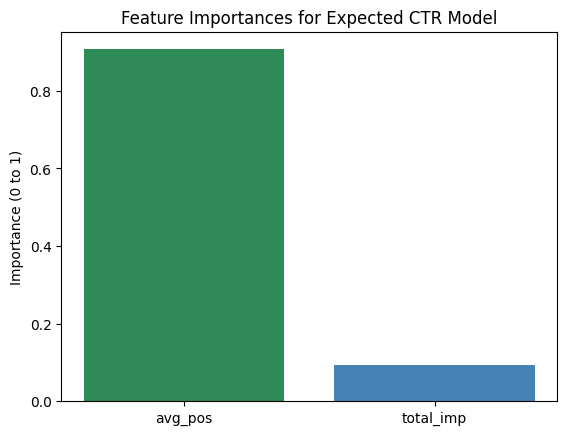


As expected, the model leans almost entirely on 'avg_pos' to predict what the CTR should be!


In [4]:
import matplotlib.pyplot as plt

print("--- What does the model lean on? ---")
importances = rf_model.feature_importances_
features = X_train.columns

plt.bar(features, importances, color=['seagreen', 'steelblue'])
plt.title('Feature Importances for Expected CTR Model')
plt.ylabel('Importance (0 to 1)')
plt.show()

print("\nAs expected, the model leans almost entirely on 'avg_pos' to predict what the CTR should be!")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.